## 1) Load data 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [7]:
import pandas as pd

arabic_data = pd.read_csv('data/ar_reviews_100k.tsv', sep='\t')

In [8]:
arabic_data

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
...,...,...
99994,Negative,معرفش ليه كنت عاوزة أكملها وهي مش عاجباني من ا...
99995,Negative,لا يستحق ان يكون في بوكنق لانه سيئ . لا شي. لا...
99996,Negative,كتاب ضعيف جدا ولم استمتع به. فى كل قصه سرد لحا...
99997,Negative,مملة جدا. محمد حسن علوان فنان بالكلمات، والوصف...


## 2) Class distribution

In [9]:
class_counts = arabic_data["label"].value_counts()
print(class_counts)

label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


In [10]:
class_pcts = arabic_data["label"].value_counts(normalize=True) * 100
print(class_pcts)

label
Positive    33.333333
Mixed       33.333333
Negative    33.333333
Name: proportion, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_3260\294690180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="deep")


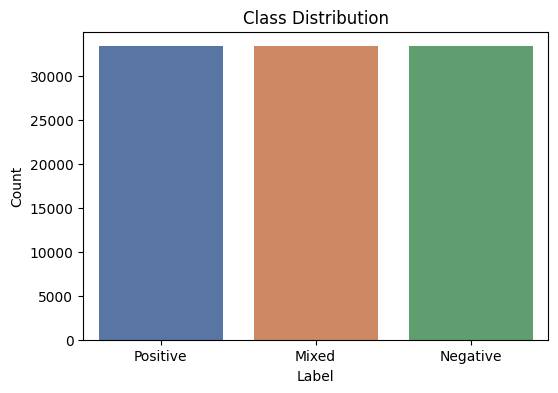

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="deep")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 3) Text length distribution

In [12]:
import nltk
from nltk.tokenize import word_tokenize


nltk.download('punkt')

# Tokenize the text column
arabic_data['tokens'] = arabic_data['text'].apply(lambda x: word_tokenize(str(x)))

# Display sample
arabic_data[['text', 'tokens']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,text,tokens
0,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,"[ممتاز, نوعا, ما, ., النظافة, والموقع, والتجهي..."
1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,"[أحد, أسباب, نجاح, الإمارات, أن, كل, شخص, في, ..."
2,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,"[هادفة, .., وقوية, ., تنقلك, من, صخب, شوارع, ا..."
3,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,"[خلصنا, .., مبدئيا, اللي, مستني, ابهار, زي, ال..."
4,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,"[ياسات, جلوريا, جزء, لا, يتجزأ, من, دبي, ., فن..."


In [13]:
arabic_data["text_length"] = arabic_data["tokens"].astype(str).str.len()
arabic_data

,label,text,tokens,text_length
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,"[ممتاز, نوعا, ما, ., النظافة, والموقع, والتجهي...",89
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,"[أحد, أسباب, نجاح, الإمارات, أن, كل, شخص, في, ...",453
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,"[هادفة, .., وقوية, ., تنقلك, من, صخب, شوارع, ا...",408
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,"[خلصنا, .., مبدئيا, اللي, مستني, ابهار, زي, ال...",934
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,"[ياسات, جلوريا, جزء, لا, يتجزأ, من, دبي, ., فن...",124
...,...,...,...,...
99994,Negative,معرفش ليه كنت عاوزة أكملها وهي مش عاجباني من ا...,"[معرفش, ليه, كنت, عاوزة, أكملها, وهي, مش, عاجب...",269
99995,Negative,لا يستحق ان يكون في بوكنق لانه سيئ . لا شي. لا...,"[لا, يستحق, ان, يكون, في, بوكنق, لانه, سيئ, .,...",155
99996,Negative,كتاب ضعيف جدا ولم استمتع به. فى كل قصه سرد لحا...,"[كتاب, ضعيف, جدا, ولم, استمتع, به, ., فى, كل, ...",125
99997,Negative,مملة جدا. محمد حسن علوان فنان بالكلمات، والوصف...,"[مملة, جدا, ., محمد, حسن, علوان, فنان, بالكلما...",260


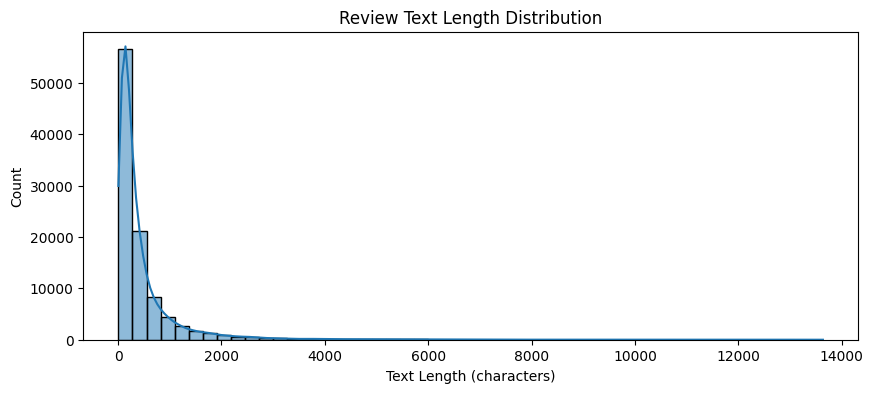

In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(arabic_data["text_length"], bins=50, kde=True)
plt.title("Review Text Length Distribution")
plt.xlabel("Text Length (characters)")
plt.show()

## 4) Most frequent words per class

In [15]:
pip install arabic-reshaper python-bidi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import nltk
nltk.download('stopwords')

punctuation = set('''!()-[]{};:'"\,<>./?@#$%^&*_~''')
arabic_data['tokens'] = arabic_data['tokens'].apply(lambda x: [word for word in x if word not in punctuation])

stopwords = set(nltk.corpus.stopwords.words('arabic'))
arabic_data['tokens'] = arabic_data['tokens'].apply(lambda x: [word for word in x if word not in stopwords])

arabic_data['tokens'].head()

<>:4: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\,'
C:\Users\User\AppData\Local\Temp\ipykernel_3260\4069732104.py:4: SyntaxWarning: invalid escape sequence '\,'
  punctuation = set('''!()-[]{};:'"\,<>./?@#$%^&*_~''')
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    [ممتاز, نوعا, النظافة, والموقع, والتجهيز, والش...
1    [أسباب, نجاح, الإمارات, شخص, الدولة, يعشق, ترا...
2    [هادفة, .., وقوية, تنقلك, صخب, شوارع, القاهرة,...
3    [خلصنا, .., مبدئيا, اللي, مستني, ابهار, زي, ال...
4    [ياسات, جلوريا, جزء, يتجزأ, دبي, فندق, متكامل,...
Name: tokens, dtype: object

In [17]:
arabic_data['tokens'] = arabic_data['tokens'].apply(lambda x: ' '.join(x))
arabic_data[['text', 'tokens']].head()

,text,tokens
0,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوعا النظافة والموقع والتجهيز والشاطيء ا...
1,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,أسباب نجاح الإمارات شخص الدولة يعشق ترابها نحب...
2,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادفة .. وقوية تنقلك صخب شوارع القاهرة الى هدو...
3,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء يتجزأ دبي فندق متكامل الخدمات...


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

vectorize = CountVectorizer()
X = vectorize.fit_transform(arabic_data['tokens'])
print(X.shape)

(99999, 309977)


In [19]:
print(arabic_data['tokens'].iloc[0])

ممتاز نوعا النظافة والموقع والتجهيز والشاطيء المطعم


In [20]:
for label in arabic_data['label'].unique():
    subset = arabic_data[arabic_data['label'] == label]
    all_tokens = [token for tokens in subset['tokens'] for token in tokens]
    most_common = pd.Series(all_tokens).value_counts().head(10)
    print(f"Label {label} - Most Common Tokens:")
    print(most_common)
    print("\n")

Label Positive - Most Common Tokens:
     1369941
ا    1089011
ل     721281
ي     464509
م     383721
و     355035
ت     352520
ر     337805
ن     302790
ب     261811
Name: count, dtype: int64


Label Mixed - Most Common Tokens:
     1397774
ا    1109634
ل     748329
ي     480122
م     388490
و     362181
ت     360681
ر     342396
ن     303660
ب     280015
Name: count, dtype: int64


Label Negative - Most Common Tokens:
     1378212
ا    1073630
ل     724751
ي     476275
م     373884
ت     351767
و     342016
ر     323521
ن     296959
ب     275855
Name: count, dtype: int64




## 5) Word cloud visualization


In [21]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


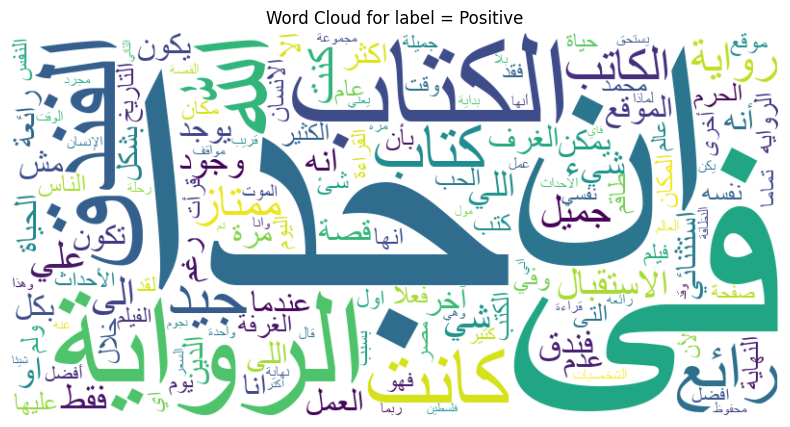

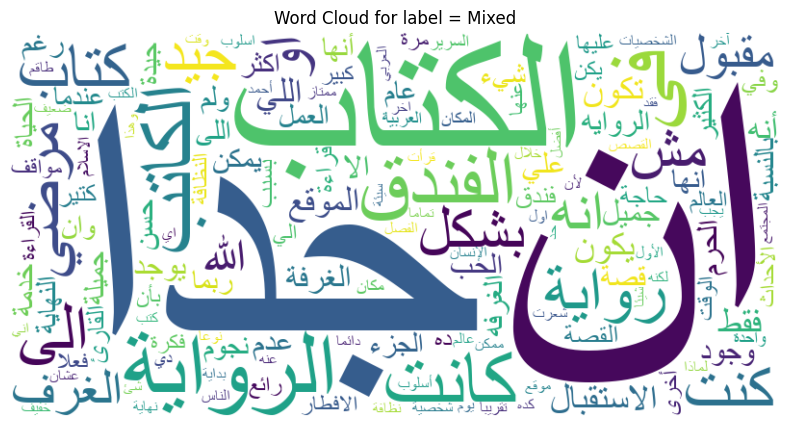

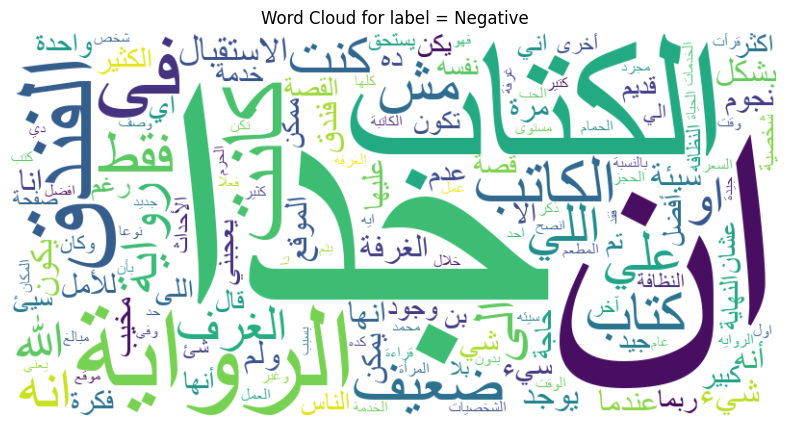

In [22]:
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display


def make_wordcloud(text, title):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)

    wc = WordCloud(
        font_path="arial.ttf",
        width=800,
        height=400,
        background_color="white",
        max_words=150,
        stopwords=stopwords,
        collocations=False,
    ).generate(bidi_text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

for label in arabic_data["label"].unique():
    texts = arabic_data.loc[arabic_data["label"] == label, "tokens"].astype(str)
    texts = texts.sample(1000, random_state=42)
    texts = " ".join(texts)
    make_wordcloud(texts, f"Word Cloud for label = {label}")

## 6) Feature extraction ( using TF-IDF ) 

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer 
arabic_vectorizer = TfidfVectorizer()
X_tfidf = arabic_vectorizer.fit_transform(arabic_data['tokens'])   
print(X_tfidf.shape)

(99999, 309977)


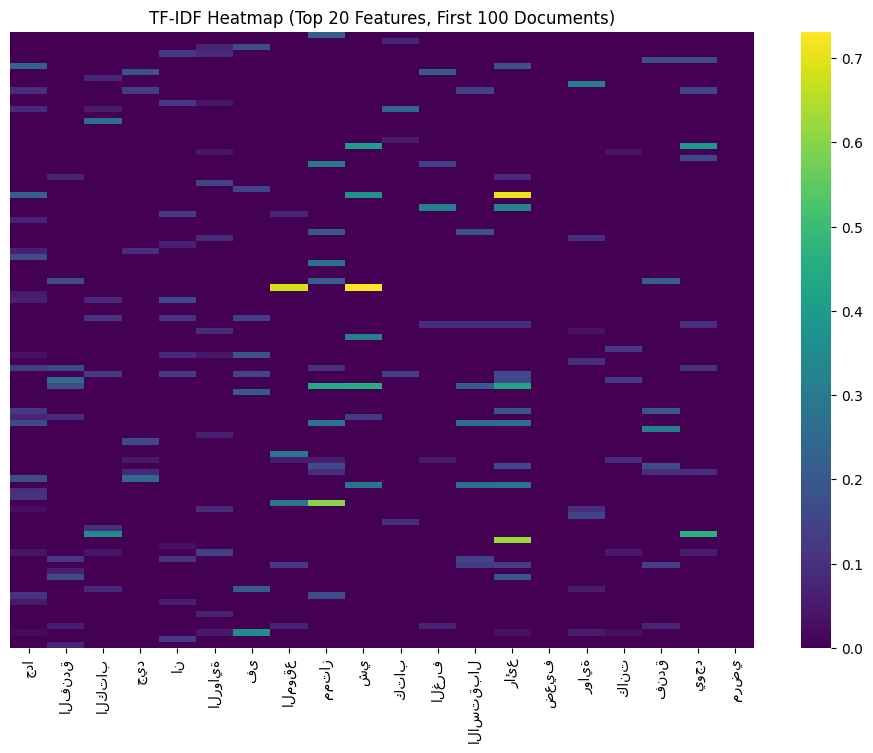

In [35]:
import seaborn as sns

# Get top 20 features
feature_names = arabic_vectorizer.get_feature_names_out()
top_features = X_tfidf.sum(axis=0).A1.argsort()[-20:][::-1]
top_feature_names = [feature_names[i] for i in top_features]

# Heatmap for first 100 documents
plt.figure(figsize=(12, 8))
sns.heatmap(X_tfidf[:100, top_features].toarray(), yticklabels=False, xticklabels=top_feature_names, cmap='viridis')
plt.title('TF-IDF Heatmap (Top 20 Features, First 100 Documents)')
plt.show()

## 7) Model Training using Gaussian Naïve Bayes  

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(arabic_data['tokens'], arabic_data['label'], test_size=0.2, random_state=42)


In [37]:
X_train_tfidf = arabic_vectorizer.fit_transform(X_train)
X_test_tfidf = arabic_vectorizer.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(79999, 275205)
(20000, 275205)


In [38]:
from sklearn.naive_bayes import MultinomialNB

arabic_model = MultinomialNB()

arabic_model.fit(X_train_tfidf, y_train)
y_pred = arabic_model.predict(X_test_tfidf)    

In [39]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       Mixed       0.56      0.58      0.57      6722
    Negative       0.67      0.72      0.69      6603
    Positive       0.71      0.63      0.67      6675

    accuracy                           0.64     20000
   macro avg       0.65      0.64      0.64     20000
weighted avg       0.65      0.64      0.64     20000



In [40]:
import pickle

pickle.dump(arabic_model, open("arabic_model.pkl", "wb"))
pickle.dump(arabic_vectorizer, open("arabic_vectorizer.pkl", "wb"))